# Beaconed vs Non-beaconed Firing Profile Stability

## What this notebook tests

In the VR task the animal runs a 200 cm linear track in two trial types:

- **Beaconed trials** (`type == 'b'`): a visible beacon (cue tower) is placed above the reward zone (90–110 cm). The animal can use this proximal landmark to locate the reward.
- **Non-beaconed trials** (`type == 'nb'`): the beacon is absent. The animal must rely on path integration or distal room cues alone.

Only **hit trials** (`performance == 'hit'`) are included — the animal entered the reward zone and received reward in both conditions — so any profile differences cannot be explained by task failure.

### Hypothesis

If a cell's spatial firing is driven by the **beacon** (a proximal, within-track landmark), its rate map should change when the beacon is removed: firing near 90–110 cm should be reduced or displaced, yielding a **low Pearson r** between beaconed and non-beaconed profiles.

If a cell encodes a **stable allocentric or self-motion-based map**, its profile should be reproducible regardless of beacon presence, yielding a **high Pearson r**.

### Matched trial sampling

Non-beaconed hit trials are typically fewer than beaconed hits. To prevent trial-count from inflating stability estimates, both conditions are sub-sampled to **N = min(N_beaconed_hits, N_non_beaconed_hits)** trials drawn uniformly at random (without replacement). Sessions with fewer than `MIN_TRIALS_EACH = 10` hits in either condition are excluded.

The key output per cell is **`profile_r`**: the Pearson correlation between the two matched trial-averaged smoothed rate maps.

### Medial-lateral axis

The same ML gradient analysis used in `vr_feature_correlation.ipynb` is applied here, asking whether beacon-dependence (low `profile_r`) or spatial stability (high `profile_r`) varies along the medial-lateral axis of MEC. Analyses are shown for all MEC principal cells (FR < 10 Hz), grid cells (GC), and non-grid spatial cells (NGS) separately.

In [16]:
import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')
from spatial_manifolds.detect_grids import curate_clusters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
source_path         = '/Users/harryclark/Downloads/COHORT12/'
CLASSIFICATIONS_CSV = '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv'
OUTPUT_CSV          = 'vr_beacon_stability_population.csv'
OVERWRITE           = False

mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

TRACK_LEN       = 200.0
N_BINS          = 100
SIGMA           = 2.5
MIN_TRIALS_EACH = 10     # minimum hits required in each condition

bin_edges   = np.linspace(0, TRACK_LEN, N_BINS + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2.0

SANITY_MOUSE = 29
SANITY_DAY   = 23
N_SHOW       = 6         # example cells (3 high-r, 3 low-r)
ML_BINS      = 10
ML_SPLIT     = 3400      # medial / lateral boundary (µm)

In [18]:
def load_vr_session(mouse, day, source_path):
    sf = f'{source_path}M{mouse}/D{day:02}/VR/'
    beh      = nap.load_file(sf + f'sub-{mouse}_day-{day:02}_ses-VR_beh.nwb')
    clusters = curate_clusters(
        nap.load_file(sf + f'sub-{mouse}_day-{day:02}_ses-VR_srt-kilosort4_clusters.npz')
    )
    return beh, clusters


def get_beaconed_hit_epoch(beh):
    trials = beh['trials']
    return trials[(trials.type == 'b') & (trials.performance == 'hit')]


def get_non_beaconed_hit_epoch(beh):
    trials = beh['trials']
    return trials[(trials.type == 'nb') & (trials.performance == 'hit')]


def sample_epoch(ep, n, rng):
    """Draw n trials uniformly at random (without replacement), preserving temporal order."""
    idx = np.sort(rng.choice(len(ep), size=n, replace=False))
    return nap.IntervalSet(start=ep.start[idx], end=ep.end[idx])


def compute_avg_firing_profile(cluster_ts, position, ep,
                               n_bins=N_BINS, track_len=TRACK_LEN, sigma=SIGMA):
    tc = nap.compute_1d_tuning_curves(
        nap.TsGroup([cluster_ts]), position,
        nb_bins=n_bins, minmax=[0.0, track_len], ep=ep,
    )[0]
    return gaussian_filter1d(np.nan_to_num(np.array(tc, dtype=float)), sigma=sigma)


def run_session_beacon(mouse, day, source_path, rng=None):
    """Load one session; compute matched beaconed vs non-beaconed profiles.

    Returns a list of row dicts (one per cell). Returns [] if the session
    has fewer than MIN_TRIALS_EACH hits in either condition.
    """
    beh, clusters = load_vr_session(mouse, day, source_path)
    ep_b  = get_beaconed_hit_epoch(beh)
    ep_nb = get_non_beaconed_hit_epoch(beh)

    n_b, n_nb = len(ep_b), len(ep_nb)
    n_min = min(n_b, n_nb)
    if n_min < MIN_TRIALS_EACH:
        return []

    if rng is None:
        rng = np.random.default_rng()
    ep_b_s  = sample_epoch(ep_b,  n_min, rng)
    ep_nb_s = sample_epoch(ep_nb, n_min, rng)

    position = beh['P']
    rows = []
    for cid in clusters.index:
        prof_b  = compute_avg_firing_profile(clusters[cid], position, ep_b_s)
        prof_nb = compute_avg_firing_profile(clusters[cid], position, ep_nb_s)
        r, pval = pearsonr(prof_b, prof_nb)
        rows.append(dict(
            mouse        = int(mouse),
            day          = int(day),
            cluster_id   = int(cid),
            brain_region = str(clusters.brain_region[cid]),
            n_b_trials   = n_b,
            n_nb_trials  = n_nb,
            n_sampled    = n_min,
            profile_r    = float(r),
            profile_pval = float(pval),
            mean_rate_b  = float(prof_b.mean()),
            mean_rate_nb = float(prof_nb.mean()),
        ))
    return rows

---
## Sanity check — M29 D23

Run one session before the full cohort. Inspect:
- Trial counts in each condition and the matched sample size
- Distribution of `profile_r` across cells
- Mean firing rate: beaconed vs non-beaconed (rate remapping check)
- Example cells at the high- and low-r extremes

In [19]:
print(f'Running sanity check: M{SANITY_MOUSE} D{SANITY_DAY} ...')
_rng_s  = np.random.default_rng(42)
rows_s  = run_session_beacon(SANITY_MOUSE, SANITY_DAY, source_path, rng=_rng_s)
df_s    = pd.DataFrame(rows_s)

if len(df_s) == 0:
    print('Session excluded — too few trials in one condition.')
else:
    print(f'  {len(df_s)} cells')
    print(f'  Beaconed hits:     {df_s["n_b_trials"].iloc[0]}')
    print(f'  Non-beaconed hits: {df_s["n_nb_trials"].iloc[0]}')
    print(f'  Sampled per cond:  {df_s["n_sampled"].iloc[0]}')
    print(f'  profile_r range:   {df_s["profile_r"].min():.3f} – {df_s["profile_r"].max():.3f}')
    print(f'  Median profile_r:  {df_s["profile_r"].median():.3f}')
    print(f'  Sig correlated (p<0.05): {(df_s["profile_pval"] < 0.05).sum()} / {len(df_s)}')

Running sanity check: M29 D23 ...
  211 cells
  Beaconed hits:     65
  Non-beaconed hits: 75
  Sampled per cond:  65
  profile_r range:   -0.203 – 0.991
  Median profile_r:  0.873
  Sig correlated (p<0.05): 208 / 211


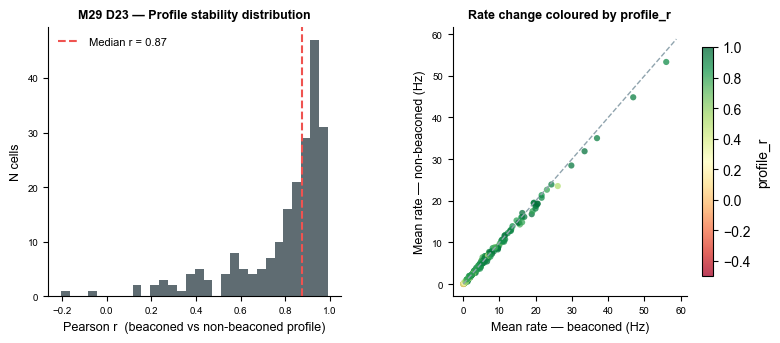

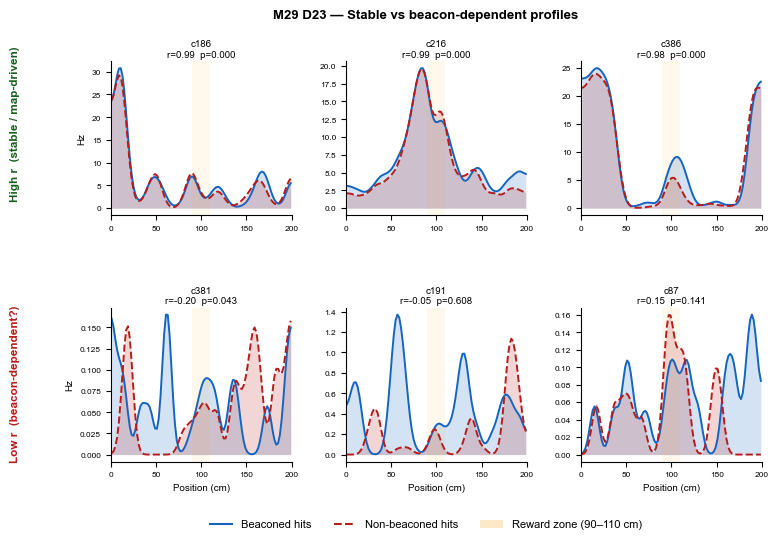

In [20]:
# Re-compute profiles with the same seed so we can overlay them
_rng_plot = np.random.default_rng(42)
beh_s, clusters_s = load_vr_session(SANITY_MOUSE, SANITY_DAY, source_path)
ep_b_all  = get_beaconed_hit_epoch(beh_s)
ep_nb_all = get_non_beaconed_hit_epoch(beh_s)
n_min_s   = min(len(ep_b_all), len(ep_nb_all))
ep_b_samp  = sample_epoch(ep_b_all,  n_min_s, _rng_plot)
ep_nb_samp = sample_epoch(ep_nb_all, n_min_s, _rng_plot)
pos_s = beh_s['P']

profs_b, profs_nb = {}, {}
for cid in clusters_s.index:
    profs_b[cid]  = compute_avg_firing_profile(clusters_s[cid], pos_s, ep_b_samp)
    profs_nb[cid] = compute_avg_firing_profile(clusters_s[cid], pos_s, ep_nb_samp)

# ── A: r distribution + rate scatter ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), gridspec_kw=dict(wspace=0.38))

ax = axes[0]
ax.hist(df_s['profile_r'], bins=30, color='#37474F', edgecolor='none', alpha=0.8)
ax.axvline(df_s['profile_r'].median(), color='#EF5350', lw=1.5, ls='--',
           label=f'Median r = {df_s["profile_r"].median():.2f}')
ax.set_xlabel('Pearson r  (beaconed vs non-beaconed profile)', fontsize=9)
ax.set_ylabel('N cells', fontsize=9)
ax.set_title(f'M{SANITY_MOUSE} D{SANITY_DAY} — Profile stability distribution',
             fontsize=9, fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

ax = axes[1]
sc = ax.scatter(df_s['mean_rate_b'], df_s['mean_rate_nb'],
                c=df_s['profile_r'], cmap='RdYlGn', vmin=-0.5, vmax=1.0,
                s=20, alpha=0.75, lw=0)
lim = max(df_s['mean_rate_b'].max(), df_s['mean_rate_nb'].max()) * 1.05
ax.plot([0, lim], [0, lim], color='#90A4AE', lw=1, ls='--')
plt.colorbar(sc, ax=ax, label='profile_r', shrink=0.85)
ax.set_xlabel('Mean rate — beaconed (Hz)', fontsize=9)
ax.set_ylabel('Mean rate — non-beaconed (Hz)', fontsize=9)
ax.set_title('Rate change coloured by profile_r', fontsize=9, fontweight='bold')
ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

plt.savefig(f'sanity_M{SANITY_MOUSE}D{SANITY_DAY}_beacon_stability_dist.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

# ── B: example profiles — high r vs low r ─────────────────────────────────────
n_each    = N_SHOW // 2
high_ids  = df_s.nlargest(n_each,  'profile_r')['cluster_id'].values
low_ids   = df_s.nsmallest(n_each, 'profile_r')['cluster_id'].values
ex_ids    = list(high_ids) + list(low_ids)

fig2, axes2 = plt.subplots(2, n_each, figsize=(n_each * 2.8, 5.2),
                            gridspec_kw=dict(hspace=0.60, wspace=0.30))
for col_i, cid in enumerate(ex_ids):
    row_i = 0 if col_i < n_each else 1
    ci    = col_i % n_each
    ax    = axes2[row_i, ci]
    r_val = df_s.loc[df_s['cluster_id'] == cid, 'profile_r'].iloc[0]
    p_val = df_s.loc[df_s['cluster_id'] == cid, 'profile_pval'].iloc[0]
    pb    = profs_b[cid]
    pnb   = profs_nb[cid]
    ax.fill_between(bin_centres, pb,  alpha=0.18, color='#1565C0', lw=0)
    ax.fill_between(bin_centres, pnb, alpha=0.18, color='#B71C1C', lw=0)
    ax.plot(bin_centres, pb,  color='#1565C0', lw=1.4, label='Beaconed')
    ax.plot(bin_centres, pnb, color='#B71C1C', lw=1.4, ls='--', label='Non-beaconed')
    ax.axvspan(90, 110, alpha=0.08, color='#F9A825', lw=0)
    ax.set_xlim(0, 200)
    ax.set_title(f'c{cid}\nr={r_val:.2f}  p={p_val:.3f}', fontsize=7, pad=3)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=6)
    if ci == 0: ax.set_ylabel('Hz', fontsize=7)
    if row_i == 1: ax.set_xlabel('Position (cm)', fontsize=7)

for ri, lbl in enumerate(['High r  (stable / map-driven)', 'Low r  (beacon-dependent?)']):
    fig2.text(0.005, 0.76 - ri * 0.50, lbl, va='center', ha='left',
              fontsize=8.5, fontweight='bold',
              color='#1B5E20' if ri == 0 else '#B71C1C', rotation=90)

handles = [
    plt.Line2D([0],[0], color='#1565C0', lw=1.5, label='Beaconed hits'),
    plt.Line2D([0],[0], color='#B71C1C', lw=1.5, ls='--', label='Non-beaconed hits'),
    plt.Rectangle((0,0),1,1, fc='#F9A825', alpha=0.25, label='Reward zone (90–110 cm)'),
]
fig2.legend(handles=handles, loc='lower center', ncol=3, fontsize=8,
            frameon=False, bbox_to_anchor=(0.5, -0.04))
fig2.suptitle(f'M{SANITY_MOUSE} D{SANITY_DAY} — Stable vs beacon-dependent profiles',
              fontsize=9.5, fontweight='bold')
plt.savefig(f'sanity_M{SANITY_MOUSE}D{SANITY_DAY}_beacon_example_profiles.pdf',
            bbox_inches='tight', dpi=150)
plt.show()

---
## Full cohort

Loops all sessions in `mouse_days`. For each session with ≥ `MIN_TRIALS_EACH` hits in both
conditions, computes matched-sampled profiles and `profile_r` for every cell. Saves to
`vr_beacon_stability_population.csv`. Set `OVERWRITE = True` in `cell-config` to force rerun.

In [21]:
if Path(OUTPUT_CSV).exists() and not OVERWRITE:
    df_pop = pd.read_csv(OUTPUT_CSV)
    print(f'Loaded {OUTPUT_CSV}: {len(df_pop)} cells, '
          f'{df_pop[["mouse","day"]].drop_duplicates().shape[0]} sessions')
else:
    all_rows = []
    RNG_POP  = np.random.default_rng(0)
    for mouse, days in mouse_days.items():
        for day in days:
            if not (Path(source_path) / f'M{mouse}' / f'D{day:02}' / 'VR').exists():
                continue
            print(f'M{mouse} D{day:02} ...', end=' ', flush=True)
            try:
                rows = run_session_beacon(mouse, day, source_path, rng=RNG_POP)
                all_rows.extend(rows)
                print(f'{len(rows)} cells' if rows else 'skipped (too few trials)')
            except Exception as e:
                print(f'ERROR: {e}')
    df_pop = pd.DataFrame(all_rows)
    df_pop.to_csv(OUTPUT_CSV, index=False)
    print(f'\nSaved {OUTPUT_CSV}: {len(df_pop)} cells, '
          f'{df_pop[["mouse","day"]].drop_duplicates().shape[0]} sessions')

print(f'\nprofile_r: {df_pop["profile_r"].min():.3f} – {df_pop["profile_r"].max():.3f}  '
      f'(median {df_pop["profile_r"].median():.3f})')
print(f'Significantly correlated (p<0.05): {(df_pop["profile_pval"] < 0.05).sum()} / {len(df_pop)}')
df_pop.head()

M20 D14 ... 204 cells
M20 D15 ... 75 cells
M20 D16 ... 219 cells
M20 D17 ... 132 cells
M20 D18 ... 151 cells
M20 D19 ... 118 cells
M20 D20 ... skipped (too few trials)
M20 D21 ... skipped (too few trials)
M20 D22 ... skipped (too few trials)
M20 D23 ... 85 cells
M20 D24 ... 81 cells
M20 D25 ... 37 cells
M20 D26 ... 154 cells
M21 D15 ... 268 cells
M21 D16 ... 242 cells
M21 D17 ... 312 cells
M21 D18 ... 219 cells
M21 D19 ... 421 cells
M21 D20 ... 331 cells
M21 D21 ... 340 cells
M21 D22 ... 164 cells
M21 D23 ... 350 cells
M21 D24 ... 229 cells
M21 D25 ... 184 cells
M21 D26 ... 209 cells
M25 D16 ... 72 cells
M25 D17 ... 68 cells
M25 D18 ... 146 cells
M25 D19 ... 61 cells
M25 D20 ... 68 cells
M25 D21 ... skipped (too few trials)
M25 D22 ... 189 cells
M25 D23 ... 229 cells
M25 D24 ... 69 cells
M25 D25 ... 152 cells
M26 D11 ... 165 cells
M26 D12 ... 156 cells
M26 D13 ... 118 cells
M26 D14 ... 29 cells
M26 D15 ... 141 cells
M26 D16 ... 48 cells
M26 D17 ... 57 cells
M26 D18 ... 103 cells
M26 D1

,mouse,day,cluster_id,brain_region,n_b_trials,n_nb_trials,n_sampled,profile_r,profile_pval,mean_rate_b,mean_rate_nb
0,20,14,34,ENTm1,91,28,28,0.620725,5.625508e-12,0.327586,0.548967
1,20,14,37,ENTm1,91,28,28,0.683951,4.400498e-15,0.815255,1.330941
2,20,14,57,ENTm1,91,28,28,0.671912,1.966749e-14,0.572407,0.615209
3,20,14,80,ENTm1,91,28,28,0.130882,1.943041e-01,3.044595,3.091647
4,20,14,85,ENTm1,91,28,28,0.753765,1.430470e-19,2.800965,2.587388


---
## Population analysis — ML gradient in profile stability

Merges population results with `cell_classifications.csv` for `|SC_x|`, `cell_type`, and
`firing_rate_VR`. Filters to MEC principal cells (`brain_region` starts with `ENTm`,
`firing_rate_VR < 10 Hz`). Repeated for all cells, GC, and NGS.

**`profile_r`** = Pearson r between matched beaconed and non-beaconed spatial firing profiles.
High values indicate beacon-independent, map-driven spatial coding.
Low values indicate the profile depends on the beacon landmark.

MEC principal cells (ENTm*, FR<10Hz): 5134
cell_type
NG       3798
Other     862
GC        474

── All MEC principal  (n=5134) ──
  Spearman r(ML, profile_r): rho=-0.042  p=0.0029
  Median profile_r — medial: 0.658   lateral: 0.648
  Mann-Whitney med vs lat:   p=0.9602


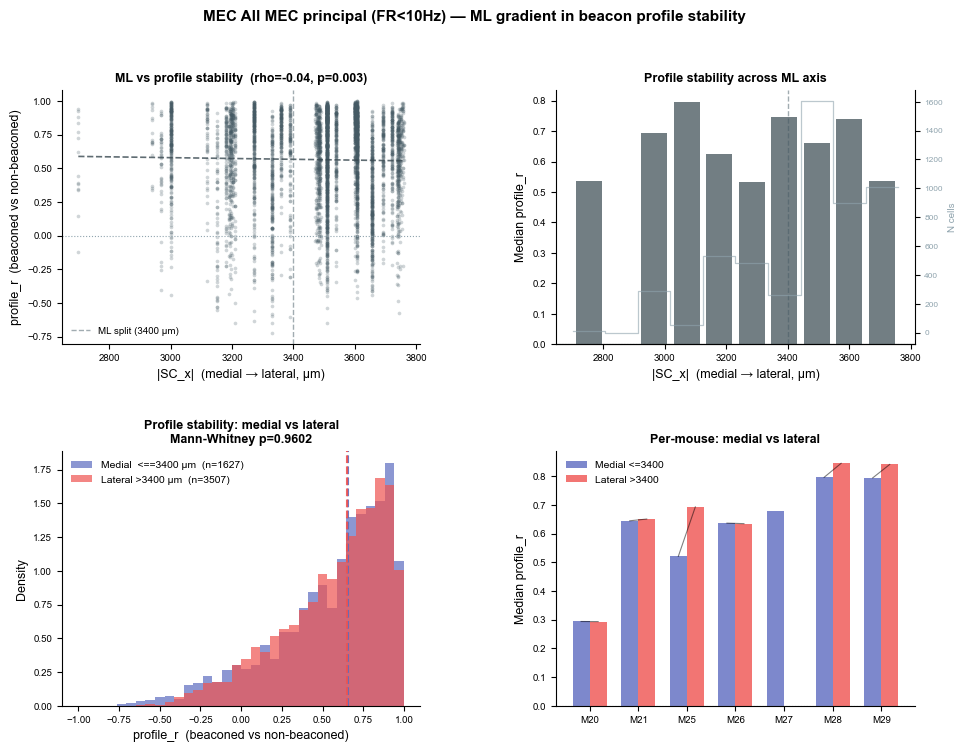


── Grid cells (GC)  (n=474) ──
  Spearman r(ML, profile_r): rho=0.137  p=0.0027
  Median profile_r — medial: 0.632   lateral: 0.675
  Mann-Whitney med vs lat:   p=0.0847


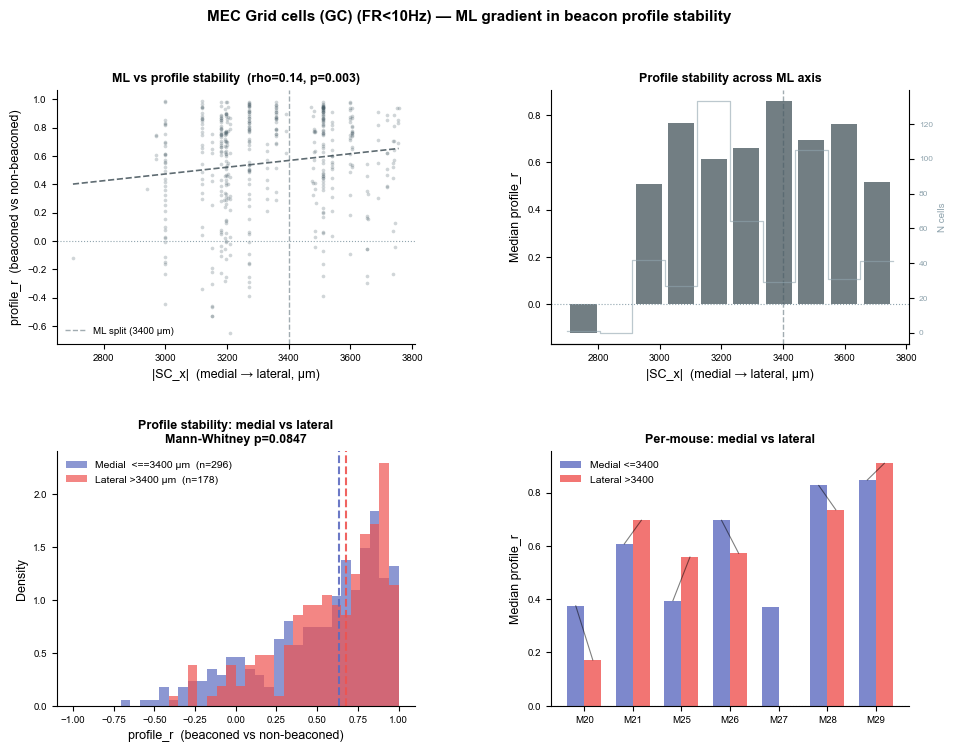


── Non-grid spatial  (n=3798) ──
  Spearman r(ML, profile_r): rho=-0.042  p=0.0090
  Median profile_r — medial: 0.672   lateral: 0.677
  Mann-Whitney med vs lat:   p=0.6167


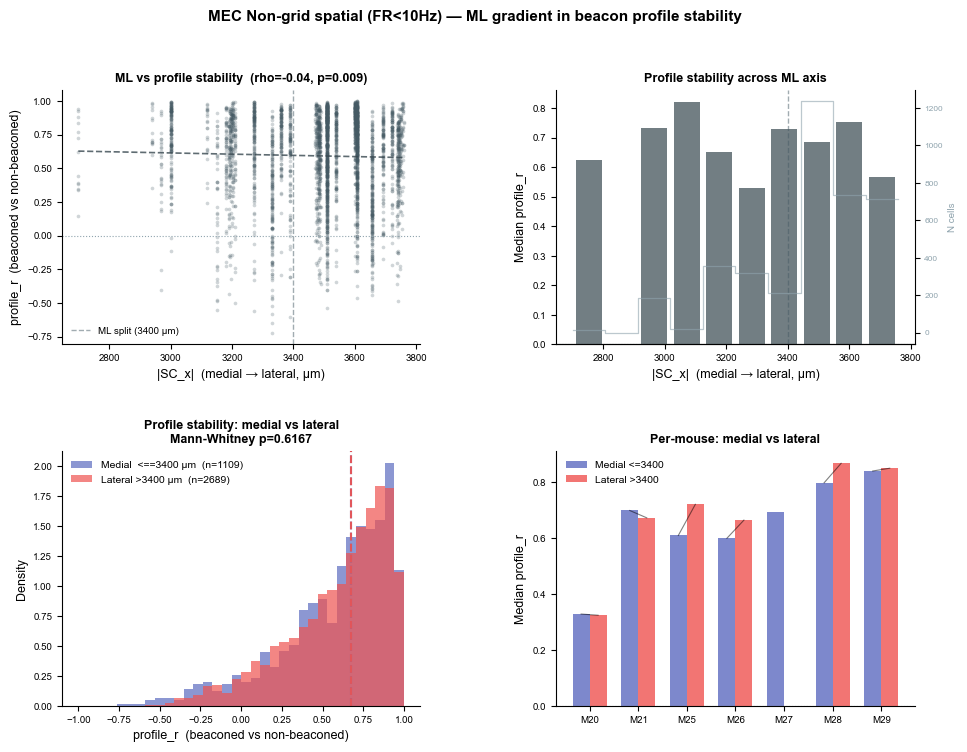

In [22]:
df_class_all = pd.read_csv(CLASSIFICATIONS_CSV)[
    ['mouse','day','cluster_id','SC_x','cell_type','firing_rate_VR']
]
df_class_all['ml']    = df_class_all['SC_x'].abs()
df_class_all['mouse'] = df_class_all['mouse'].astype(int)
df_class_all['day']   = df_class_all['day'].astype(int)
df_pop['mouse']        = df_pop['mouse'].astype(int)
df_pop['day']          = df_pop['day'].astype(int)

df_merged_all = df_pop.merge(df_class_all, on=['mouse','day','cluster_id'], how='inner')
df_merged_all = df_merged_all[
    df_merged_all['brain_region'].str.startswith('ENTm', na=False) &
    (df_merged_all['firing_rate_VR'] < 10)
].copy()

print(f'MEC principal cells (ENTm*, FR<10Hz): {len(df_merged_all)}')
print(df_merged_all['cell_type'].value_counts().to_string())

CELL_TYPE_GROUPS = [
    ('all',  'All MEC principal',  df_merged_all),
    ('GC',   'Grid cells (GC)',    df_merged_all[df_merged_all['cell_type'] == 'GC']),
    ('NGS',  'Non-grid spatial',   df_merged_all[df_merged_all['cell_type'] == 'NG']),
]

for ct_key, ct_label, df in CELL_TYPE_GROUPS:
    if len(df) == 0:
        print(f'No cells for {ct_label} — skipping')
        continue

    medial_r  = df[df['ml'] <= ML_SPLIT]['profile_r'].dropna()
    lateral_r = df[df['ml'] >  ML_SPLIT]['profile_r'].dropna()
    rho, rho_p = spearmanr(df['ml'], df['profile_r'])
    _, mwu_p   = mannwhitneyu(medial_r, lateral_r, alternative='two-sided') \
                 if len(medial_r) > 1 and len(lateral_r) > 1 else (np.nan, np.nan)

    print(f'\n── {ct_label}  (n={len(df)}) ──')
    print(f'  Spearman r(ML, profile_r): rho={rho:.3f}  p={rho_p:.4f}')
    print(f'  Median profile_r — medial: {medial_r.median():.3f}   lateral: {lateral_r.median():.3f}')
    print(f'  Mann-Whitney med vs lat:   p={mwu_p:.4f}')

    fig, axes = plt.subplots(2, 2, figsize=(11, 8),
                             gridspec_kw=dict(hspace=0.42, wspace=0.38))

    # A: ML vs profile_r scatter
    ax = axes[0, 0]
    ax.scatter(df['ml'], df['profile_r'], s=7, color='#455A64', alpha=0.25, lw=0)
    ml_s = np.sort(df['ml'].values)
    ax.plot(ml_s, np.polyval(np.polyfit(df['ml'], df['profile_r'], 1), ml_s),
            color='#37474F', lw=1.2, ls='--', alpha=0.8)
    ax.axhline(0, color='#90A4AE', lw=0.8, ls=':')
    ax.axvline(ML_SPLIT, color='#455A64', lw=1.0, ls='--', alpha=0.5,
               label=f'ML split ({ML_SPLIT} µm)')
    ax.set_xlabel('|SC_x|  (medial → lateral, µm)', fontsize=9)
    ax.set_ylabel('profile_r  (beaconed vs non-beaconed)', fontsize=9)
    ax.set_title(f'ML vs profile stability  (rho={rho:.2f}, p={rho_p:.3f})',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, frameon=False)
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

    # B: median profile_r per ML bin
    ax = axes[0, 1]
    ml_vals = df['ml'].values
    edges   = np.linspace(ml_vals.min(), ml_vals.max(), ML_BINS + 1)
    ctrs    = (edges[:-1] + edges[1:]) / 2
    med_r   = np.array([df[(ml_vals >= e0) & (ml_vals < e1)]['profile_r'].median()
                        for e0, e1 in zip(edges[:-1], edges[1:])])
    n_all   = np.array([np.sum((ml_vals >= e0) & (ml_vals < e1))
                        for e0, e1 in zip(edges[:-1], edges[1:])])
    ax.bar(ctrs, med_r, width=np.diff(edges) * 0.8, color='#37474F', alpha=0.70, lw=0)
    ax.axhline(0, color='#90A4AE', lw=0.8, ls=':')
    ax.axvline(ML_SPLIT, color='#455A64', lw=1.0, ls='--', alpha=0.5)
    axb = ax.twinx()
    axb.step(edges, np.append(n_all, n_all[-1]), color='#90A4AE', lw=0.9,
             where='post', alpha=0.6)
    axb.set_ylabel('N cells', fontsize=7, color='#90A4AE')
    axb.tick_params(labelsize=6, labelcolor='#90A4AE')
    axb.spines[['top','left']].set_visible(False)
    ax.set_xlabel('|SC_x|  (medial → lateral, µm)', fontsize=9)
    ax.set_ylabel('Median profile_r', fontsize=9)
    ax.set_title('Profile stability across ML axis', fontsize=9, fontweight='bold')
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

    # C: profile_r distribution medial vs lateral
    ax = axes[1, 0]
    bins_r = np.linspace(-1, 1, 35)
    ax.hist(medial_r,  bins=bins_r, color='#5C6BC0', alpha=0.70, density=True,
            edgecolor='none', label=f'Medial  <=={ML_SPLIT} µm  (n={len(medial_r)})')
    ax.hist(lateral_r, bins=bins_r, color='#EF5350', alpha=0.70, density=True,
            edgecolor='none', label=f'Lateral >{ML_SPLIT} µm  (n={len(lateral_r)})')
    ax.axvline(medial_r.median(),  color='#5C6BC0', lw=1.5, ls='--', alpha=0.9)
    ax.axvline(lateral_r.median(), color='#EF5350', lw=1.5, ls='--', alpha=0.9)
    ax.set_xlabel('profile_r  (beaconed vs non-beaconed)', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_title(f'Profile stability: medial vs lateral\nMann-Whitney p={mwu_p:.4f}',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=7.5, frameon=False)
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

    # D: per-mouse median profile_r medial vs lateral
    ax = axes[1, 1]
    mice = sorted(df['mouse'].unique())
    x_med, x_lat = [], []
    for mouse in mice:
        sub = df[df['mouse'] == mouse]
        x_med.append(sub[sub['ml'] <= ML_SPLIT]['profile_r'].median())
        x_lat.append(sub[sub['ml'] >  ML_SPLIT]['profile_r'].median())
    x = np.arange(len(mice)); w = 0.35
    ax.bar(x - w/2, x_med, w, color='#5C6BC0', alpha=0.80, lw=0,
           label=f'Medial <={ML_SPLIT}')
    ax.bar(x + w/2, x_lat, w, color='#EF5350', alpha=0.80, lw=0,
           label=f'Lateral >{ML_SPLIT}')
    for xi, fm, fl in zip(x, x_med, x_lat):
        if np.isfinite(fm) and np.isfinite(fl):
            ax.plot([xi - w/2, xi + w/2], [fm, fl], color='k', lw=0.8, alpha=0.5)
    ax.axhline(0, color='#90A4AE', lw=0.8, ls=':')
    ax.set_xticks(x)
    ax.set_xticklabels([f'M{m}' for m in mice], fontsize=7)
    ax.set_ylabel('Median profile_r', fontsize=9)
    ax.set_title('Per-mouse: medial vs lateral', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7.5, frameon=False)
    ax.spines[['top','right']].set_visible(False); ax.tick_params(labelsize=7)

    fig.suptitle(f'MEC {ct_label} (FR<10Hz) — ML gradient in beacon profile stability',
                 fontsize=11, fontweight='bold')
    plt.savefig(f'population_beacon_stability_ML_{ct_key}.pdf', bbox_inches='tight', dpi=150)
    plt.show()